# GRACE universal potentials in LAMMPS, via `lammpsparser`

This notebook demonstrates how to run a [GRACE](https://gracemaker.readthedocs.io/en/latest/gracemaker/tutorials/#132-lammps) machine-learning interatomic potential in [LAMMPS](https://www.lammps.org), using the native `pair_style grace/fs` evaluator that ships in the `conda-forge` LAMMPS package (`2025.07.22`, build `5`).

Rather than hand-writing a LAMMPS input script, we drive LAMMPS through [`lammpsparser`](https://lammpsparser.readthedocs.io/en/latest/example.html) - a thin, file-based Python wrapper around LAMMPS that many computational-materials users already know from `pyiron`. It writes the LAMMPS data file and input script, runs `lmp_mpi`, and parses the log/dump files back into `numpy` arrays in ASE units.

We use it here in two steps:
1. A single-point (static) energy/force evaluation.
2. A short NVT molecular-dynamics trajectory, with the resulting temperature and energy parsed    and plotted directly from LAMMPS' output files.

**Why `grace/fs` and not `pair_style grace`?** The full GRACE evaluator (`pair_style grace` and its chunked/parallel variants) executes the model as a TensorFlow `SavedModel` and needs LAMMPS linked against `libtensorflow`. The `conda-forge` LAMMPS package builds without that link (`-D NO_GRACE_TF=yes`), so only the native, TensorFlow-free evaluator - `pair_style grace/fs`, for GRACE's simpler "FS-like" model family - is actually compiled in. It's also the faster option on CPU.

## 1. Get a GRACE/FS foundation model

`grace/fs` reads a native YAML file, not the TensorFlow `SavedModel` directory that `grace_models download` fetches. That native file is exported from a model *checkpoint* with the `grace_utils` CLI (both ships with the `grace-tensorpotential` package - the LAMMPS/CPU-friendly conda-forge packaging of `tensorpotential`, the code behind GRACE).

We use `GRACE-FS-OAM`, an FS-family model fitted on OMat24 and fine-tuned on sAlex+MPtrj.

In [1]:
import os

model_name = "GRACE-FS-OAM"
checkpoint_dir = os.path.expanduser(os.path.join("~/.cache/grace/checkpoints", model_name))
fs_model_path = os.path.join(checkpoint_dir, "FS_model.yaml")

!grace_models checkpoint {model_name}
!grace_utils -p {checkpoint_dir}/model.yaml -c {checkpoint_dir}/checkpoint export -sf -n {fs_model_path}

[tensorpotential] Info: Environment variable TF_USE_LEGACY_KERAS is automatically set to '1'.
[tensorpotential] Info: tf.experimental.numpy behavior enabled.
[tensorpotential] Info: TensorFloat-32 execution disabled.
GRACE-FS-OAM (archive): 100%|███████████████| 627k/627k [00:00<00:00, 2.91MB/s]
Unpacking model from 'https://huggingface.co/AMS-ICAMS-RUB/grace-foundation-models/resolve/kk/checkpoints/GRACE-FS-OAM-checkpoint.tar.gz' (local file: /home/jovyan/.cache/grace/checkpoints/tmp.tar.gz) to /home/jovyan/.cache/grace/checkpoints
GRACE model checkpoint downloaded to /home/jovyan/.cache/grace/checkpoints/GRACE-FS-OAM
Model license: Academic Software License
Checkpoint for GRACE-FS-OAM downloaded successfully.
[tensorpotential] Info: Environment variable TF_USE_LEGACY_KERAS is automatically set to '1'.
[tensorpotential] Info: tf.experimental.numpy behavior enabled.
[tensorpotential] Info: TensorFloat-32 execution disabled.
2026/09/20 10:30:16 I - No param_dtype in model.yaml (old mode

## 2. Build the structure and register the potential

`lammpsparser` looks up classical potentials by name in the NIST/OpenKIM database via `get_potential_by_name`, which does not know about GRACE. Instead we hand it a `pandas.Series` with the same shape that function would normally return: a `pair_style`/`pair_coeff` pair pointing at the exported FS model.

In [2]:
import pandas as pd
from ase.build import bulk

element = "Al"

# A small fcc aluminium supercell (32 atoms)
structure = bulk(element, cubic=True).repeat((2, 2, 2))

# lammpsparser normally resolves `potential` via `get_potential_by_name()` against the
# NIST/OpenKIM potential database. GRACE models are not in that database, so we build the
# equivalent `pandas.Series` by hand and pass it in directly.
potential = pd.Series(
    {
        "Name": model_name,
        "Species": [element],
        "Config": [
            "pair_style grace/fs",
            f"pair_coeff * * {fs_model_path} {element}",
        ],
    }
)
potential

Name                                            GRACE-FS-OAM
Species                                                 [Al]
Config     [pair_style grace/fs, pair_coeff * * /home/jov...
dtype: object

## 3. Static energy and force evaluation

`lammps_file_interface_function()` writes the LAMMPS data file and input script, runs `lmp_mpi`, and parses `log.lammps`/`dump.out` back into ASE units.

In [3]:
from lammpsparser import lammps_file_interface_function

shell_output, static_output, job_crashed = lammps_file_interface_function(
    working_directory="lmp_static",
    structure=structure,
    potential=potential,
    calc_mode="static",
)

assert not job_crashed
print("Potential energy (eV):", static_output["generic"]["energy_pot"][-1])
print("Max. force component (eV/A):", abs(static_output["generic"]["forces"][-1]).max())

Potential energy (eV): -119.204486704084
Max. force component (eV/A): 3.06005221162309e-15


## 4. Short NVT molecular-dynamics run

Same potential, `calc_mode="md"`: `lammpsparser` adds the thermostat, velocity initialisation and dump/thermo commands for us.

In [4]:
shell_output, md_output, job_crashed = lammps_file_interface_function(
    working_directory="lmp_md",
    structure=structure,
    potential=potential,
    calc_mode="md",
    calc_kwargs={
        "temperature": 500.0,
        "n_ionic_steps": 500,
        "n_print": 25,
        "time_step": 1.0,
        "seed": 12345,
    },
)

assert not job_crashed

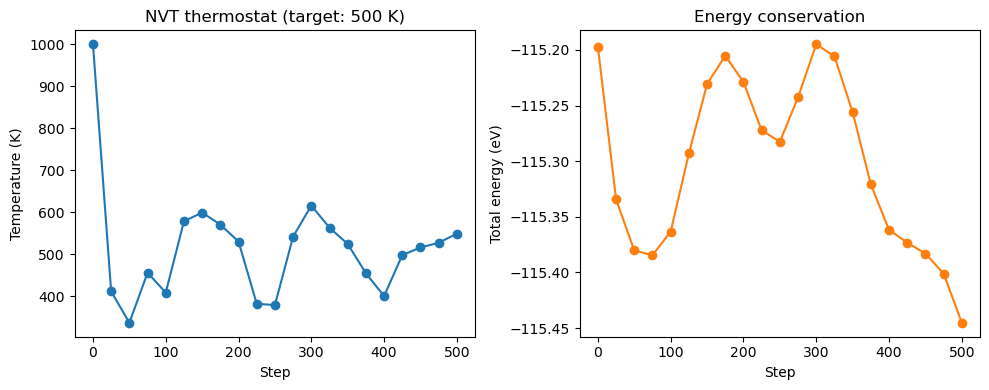

In [5]:
%matplotlib inline
import matplotlib.pyplot as plt

steps = md_output["generic"]["steps"]
temperature = md_output["generic"]["temperature"]
energy_tot = md_output["generic"]["energy_tot"]

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].plot(steps, temperature, marker="o")
axes[0].set_xlabel("Step")
axes[0].set_ylabel("Temperature (K)")
axes[0].set_title("NVT thermostat (target: 500 K)")

axes[1].plot(steps, energy_tot, marker="o", color="tab:orange")
axes[1].set_xlabel("Step")
axes[1].set_ylabel("Total energy (eV)")
axes[1].set_title("Energy conservation")

fig.tight_layout()
plt.show()